Workshop: Seeing Through the Eyes of a CNN 👁️🧠
Hopefully you enjoyed training your first neural network to recognise images in the last workshop. Now we're going to do something a bit mind-bending: instead of asking "what class is this image?", we're going to ask "what would the network's favourite image of this class look like?"

This technique is called class visualisation (or activation maximisation), and it's one of the main tools researchers use to peek inside the "black box" of a CNN and understand what it's actually looking for.

The big idea 💡
Normally, training works like this:

image  →  network  →  prediction  →  compare to true label  →  update NETWORK WEIGHTS

Today we're going to flip it on its head:

target class  →  network (frozen!)  →  score  →  update the IMAGE PIXELS

Everything you already know about gradient descent, loss functions and backpropagation still applies — we're just backpropagating all the way through the network into the pixels themselves, instead of stopping at the weights.

Think🤔: In the last workshop, requires_grad=True was set on the model's weights so the optimiser could update them. This time, we're going to do the opposite — freeze the weights and instead set requires_grad=True on the image. Why do you think that is?

We'll use a ResNet50, a much deeper CNN than the simple models you've built so far, pretrained on ImageNet (1.2 million photos, 1000 classes — everything from flamingos to soccer balls).

By the end of this workshop you'll:

Build a naive version that backpropagates into an image — and see why it looks like multicoloured noise 🌈
Fix it with a better loss function and a smart constraint that forces the image to be grayscale
Peek into different layers of the network to see how simple edges and textures build up into complex objects
Let's get started!

Task 0: Setup 🛠️
First, let's load our pretrained network. Since we're not training the network itself, we freeze every parameter — this guarantees any gradient we compute only flows back into the image, not into the network's weights.

In [1]:
import torch
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

# Use a GPU if available -- this will be MUCH faster
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load a ResNet50 pretrained on ImageNet
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.eval()        # Tell the model we're not training it (affects things like dropout)
model.to(device)

# TODO: Freeze every parameter in the model so gradients don't update the network's weights
for param in model.parameters():
    param.requires_grad_(False)   # <-- fill this in: True or False?


Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s] 


Think🤔: If you accidentally left requires_grad_(True) here, what do you think would happen when we try to update "the image"? Would the network's weights start changing too?

ImageNet images are normally normalised using fixed mean/std values (this is just how the network was trained, so we must match it). We'll also write a little helper to convert a normalised tensor back into a displayable image.

In [2]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

def normalise(img):
    """Convert a [0,1] image tensor into ImageNet-normalised space."""
    return (img - IMAGENET_MEAN) / IMAGENET_STD

def deprocess(img_tensor):
    """Convert a tensor back into a displayable [0,1] numpy image."""
    img = img_tensor.detach().cpu().clone().squeeze(0)
    img = img.permute(1, 2, 0).numpy()   # (C, H, W) -> (H, W, C) for matplotlib
    return np.clip(img, 0, 1)

Task 1: Our First (Naive) Class Visualisation 🎨
Here's the plan, step by step — it should feel very familiar from the training loop you wrote last time:

Start with an image of random noise.
Run it through the network (forward pass).
Look at the score for our target class.
Backpropagate to find out: "which direction should each pixel move to increase this score?"
Nudge the pixels in that direction with our optimiser.
Repeat hundreds of times.
One subtlety: our optimiser (Adam) is built to minimise a loss, but we want to maximise a class score. The trick is simple — minimising the negative of something is the same as maximising it.

In [4]:
def visualise_class_naive(
    target_class: int,
    num_iterations: int = 300,
    lr: float = 0.1,
    l2_decay: float = 1e-4,
    img_size: int = 224,
):
    img = torch.randn(1, 3, img_size, img_size, device=device) * 0.01 + 0.5

    # We want gradients w.r.t. the IMAGE now
    img.requires_grad_(True)

    optimizer = torch.optim.Adam([img], lr=lr)

    for i in range(num_iterations):
        optimizer.zero_grad()

        with torch.no_grad():
            img.clamp_(0, 1)

        scores = model(normalise(img))

        # Minimising the NEGATIVE score is equivalent to maximising the score
        class_loss = -1 * scores[0, target_class]

        reg_loss = l2_decay * torch.norm(img)

        loss = class_loss + reg_loss

        loss.backward()
        optimizer.step()

        if i % 50 == 0 or i == num_iterations - 1:
            print(f"Iter {i:4d} | class score: {-class_loss.item():.3f}")

    return deprocess(img)


Now let's run it! Here are a few ImageNet class indices to try:

Index	Class
130	flamingo
281	tabby cat
340	zebra
805	soccer ball

Iter    0 | class score: -0.127
Iter   50 | class score: 48.386
Iter  100 | class score: 72.237
Iter  150 | class score: 78.316
Iter  200 | class score: 91.021
Iter  250 | class score: 95.101
Iter  299 | class score: 100.237


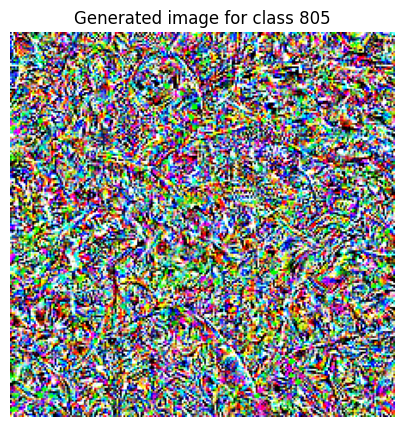

In [5]:
# TODO: pick a target class from the table above
target_class = 805

result_img = visualise_class_naive(target_class)

plt.figure(figsize=(5, 5))
plt.imshow(result_img)
plt.axis("off")
plt.title(f"Generated image for class {target_class}")
plt.show()


Think🤔: Run this a few times with different target_class values. The result probably looks like a psychedelic mess of colour rather than an actual flamingo or zebra! The network's class score is genuinely high though. What do you think is going on — is the network "wrong", or is it finding a real weakness in how we set up the problem?

Hint: CNNs are extremely sensitive to high-frequency pixel patterns (tiny speckled noise) — far more sensitive than we are. Nothing in our loss function is stopping the optimiser from exploiting that.

Task 2: A Smarter Loss Function 🧪
Let's fix the two problems we just saw:

High-frequency noise — nothing is discouraging the image from being speckled.
Garish, saturated colours — nothing is discouraging unnatural colour combinations.
Fixing the noise: a 3-term loss
We'll replace our loss with three clearly-named ingredients:

loss = -act_wt * rms + pxl_inty + im_grd

Term	What it does
rms	How strongly the target class is activated (what we want to maximise)
pxl_inty	Penalises large pixel values — keeps things from becoming over-saturated
im_grd	Penalises sharp pixel-to-pixel jumps — encourages smooth, natural-looking regions
Think🤔: im_grd is the key ingredient fighting the speckled noise. Can you guess, just from its name, how it might be calculated? (Hint: think about subtracting each pixel from its neighbour.)


In [6]:
def compute_loss(img, activation, act_wt=1.0, pxl_wt=1e-4, grd_wt=1e-3):
    """
    activation: the already-extracted tensor we want to maximise.
        - For a class logit: scores[:, target_class]
        - For a conv channel: hook.activations[:, channel]
    """
    rms = torch.sqrt(torch.mean(activation ** 2) + 1e-8)

    pxl_inty = pxl_wt * torch.mean(img ** 2)

    diff_h = img[:, :, 1:, :] - img[:, :, :-1, :]
    diff_w = img[:, :, :, 1:] - img[:, :, :, :-1]
    im_grd = grd_wt * (diff_h.abs().mean() + diff_w.abs().mean())

    loss = -act_wt * rms + pxl_inty + im_grd
    return loss, rms, pxl_inty, im_grd


Fixing the colour: a structural trick, not a penalty
Instead of penalising weird colours in the loss (which the optimiser can still fight against), we're going to make it structurally impossible for the image to have colour at all.

The trick: optimise a single-channel (grayscale) image, and only expand it to 3 identical R=G=B channels right before feeding it to the network.

In [7]:
def to_rgb(img_gray):
    """Replicate the single channel to 3 channels.
    Since there's only ONE learnable value per pixel, R, G and B
    can never differ -- colour becomes structurally impossible."""
    return img_gray.repeat(1, 3, 1, 1)


Think🤔: Why might removing a constraint directly from the parameters (grayscale-by-construction) work better than adding a penalty to the loss (e.g. "penalise the difference between R, G and B")? Which one is the optimiser more likely to find a sneaky way around?

Putting it together

In [9]:
def visualise_class(
    target_class: int,
    octave_sizes=(64, 112, 176, 224),
    iters_per_octave=150,
    lr=0.05,
    act_wt=1.0,
    pxl_wt=1e-4,
    grd_wt=1e-3,
):
    img = torch.randn(1, 1, octave_sizes[0], octave_sizes[0], device=device) * 0.01 + 0.5
    img.requires_grad_(True)

    for octave, size in enumerate(octave_sizes):
        if octave > 0:
            with torch.no_grad():
                img = F.interpolate(img, size=(size, size), mode="bilinear", align_corners=False)
            img.requires_grad_(True)

        optimizer = torch.optim.Adam([img], lr=lr)

        for i in range(iters_per_octave):
            optimizer.zero_grad()

            with torch.no_grad():
                img.clamp_(0, 1)

            img_rgb = to_rgb(img)
            scores = model(normalise(img_rgb))

            # Extract the activation HERE, before calling compute_loss
            activation = scores[:, target_class]

            loss, rms, pxl_inty, im_grd = compute_loss(
                img, activation, act_wt, pxl_wt, grd_wt
            )
            loss.backward()
            optimizer.step()

            if i % 50 == 0:
                print(f"Octave {octave} ({size}px) | iter {i:3d} | "
                      f"rms: {rms.item():.3f} | pxl_inty: {pxl_inty.item():.4f} | "
                      f"im_grd: {im_grd.item():.4f}")

    with torch.no_grad():
        img.clamp_(0, 1)

    return img.detach().cpu().squeeze(0).squeeze(0).clamp(0, 1).numpy()


Octave 0 (64px) | iter   0 | rms: 4.028 | pxl_inty: 0.0000 | im_grd: 0.0000
Octave 0 (64px) | iter  50 | rms: 86.837 | pxl_inty: 0.0000 | im_grd: 0.0006
Octave 0 (64px) | iter 100 | rms: 102.101 | pxl_inty: 0.0000 | im_grd: 0.0006
Octave 1 (112px) | iter   0 | rms: 5.757 | pxl_inty: 0.0000 | im_grd: 0.0002
Octave 1 (112px) | iter  50 | rms: 62.385 | pxl_inty: 0.0000 | im_grd: 0.0006
Octave 1 (112px) | iter 100 | rms: 90.670 | pxl_inty: 0.0000 | im_grd: 0.0006
Octave 2 (176px) | iter   0 | rms: 3.337 | pxl_inty: 0.0000 | im_grd: 0.0003
Octave 2 (176px) | iter  50 | rms: 64.047 | pxl_inty: 0.0000 | im_grd: 0.0006
Octave 2 (176px) | iter 100 | rms: 78.719 | pxl_inty: 0.0000 | im_grd: 0.0006
Octave 3 (224px) | iter   0 | rms: 10.893 | pxl_inty: 0.0000 | im_grd: 0.0003
Octave 3 (224px) | iter  50 | rms: 72.250 | pxl_inty: 0.0000 | im_grd: 0.0006
Octave 3 (224px) | iter 100 | rms: 88.665 | pxl_inty: 0.0000 | im_grd: 0.0006


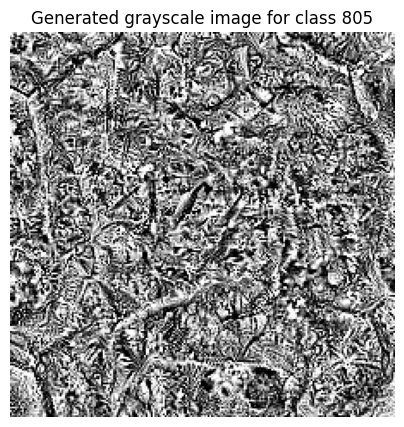

In [10]:
target_class = 805  # try the same class as before, for comparison!

result_img = visualise_class(target_class)

plt.figure(figsize=(5, 5))
plt.imshow(result_img, cmap="gray")
plt.axis("off")
plt.title(f"Generated grayscale image for class {target_class}")
plt.show()


Think🤔: Compare this result to your Task 1 image side by side. Is the shape/texture more recognisable now, even without colour?

Extension😈: Try tweaking pxl_wt and grd_wt. What happens if you set grd_wt very high (e.g. 0.1)? What about very low (e.g. 0)? Can you find a sweet spot?

Task 3: Looking at Different Layers 🔬
So far we've only been maximising the network's final output — its overall "how flamingo-y is this?" score. But a CNN is built from many stacked layers, and each one detects something different:

Early layers (model.layer1) → simple things like edges, colour blobs, basic textures
Middle layers (model.layer2, model.layer3) → combinations of edges forming textures and parts (feathers, fur, wheels...)
Late layers (model.layer4, final output) → whole objects and complex concepts
Think🤔: Given that later layers encode more complex ideas, do you think images that maximise them will be easier or harder to keep visually clean compared to earlier layers? Why might there be many different "noisy" ways to trigger a complex class, but only a few clean ways to trigger a simple edge detector?

Peeking inside with hooks
To visualise an intermediate layer (not just the final output), we need a way to grab its activations mid-forward-pass. PyTorch lets us do this with a hook — a small function that runs automatically whenever a chosen layer produces an output.

In [11]:
class LayerHook:
    """Attaches to a layer and stores whatever it outputs during a forward pass."""
    def __init__(self, module):
        self.activations = None
        self.hook = module.register_forward_hook(self._hook_fn)

    def _hook_fn(self, module, input, output):
        self.activations = output

    def remove(self):
        self.hook.remove()


One more improvement: Expectation over Transformation (EOT)
Here's a powerful trick: instead of computing the gradient from a single forward pass, we'll run the image through the network several times, each time with a small random jitter/rotation/flip applied, and average the resulting gradients.

Think🤔: This might remind you of batching from the MNIST workshop, where we averaged gradients over several images before updating the model's weights. Here we're averaging over several transformed copies of the same image before updating its pixels. Why might averaging over many slightly-different "views" discourage noisy, fragile patterns and encourage robust, recognisable ones?

In [12]:
import torchvision.transforms.functional as TF
import random

def random_transform(img, max_jitter=12, scale_range=(0.95, 1.05), max_angle=8):
    h, w = img.shape[-2:]

    pad = max_jitter
    img = F.pad(img, (pad, pad, pad, pad), mode="reflect")
    dx, dy = random.randint(0, 2 * pad), random.randint(0, 2 * pad)
    img = img[:, :, dy:dy + h, dx:dx + w]

    scale = random.uniform(*scale_range)
    new_h, new_w = int(h * scale), int(w * scale)
    img = F.interpolate(img, size=(new_h, new_w), mode="bilinear", align_corners=False)
    img = TF.center_crop(img, [h, w]) if scale > 1 else F.pad(
        img, [(w - new_w) // 2] * 2 + [(h - new_h) // 2] * 2, mode="reflect"
    )

    angle = random.uniform(-max_angle, max_angle)
    img = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)

    if random.random() < 0.5:
        img = torch.flip(img, dims=[-1])

    return img


Now let's write a flexible visualise function that can target either the final class logit or a channel in any intermediate layer — this is what lets us directly compare them.

In [13]:
def visualise(
    get_activation,
    layer_module=None,
    octave_sizes=(64, 112, 176, 224),
    iters_per_octave=150,
    lr_start=0.05,
    lr_end=0.01,
    act_wt=1.0,
    pxl_wt=1e-4,
    grd_wt=5e-3,
    n_transforms=4,
):
    hook = LayerHook(layer_module) if layer_module is not None else None

    img = torch.randn(1, 1, octave_sizes[0], octave_sizes[0], device=device) * 0.01 + 0.5
    img.requires_grad_(True)

    for octave, size in enumerate(octave_sizes):
        if octave > 0:
            with torch.no_grad():
                img = F.interpolate(img, size=(size, size), mode="bilinear", align_corners=False)
            img.requires_grad_(True)

        # Linearly decay the learning rate from lr_start to lr_end across octaves
        progress = octave / max(len(octave_sizes) - 1, 1)
        lr = lr_start + (lr_end - lr_start) * progress
        optimizer = torch.optim.Adam([img], lr=lr)

        for i in range(iters_per_octave):
            optimizer.zero_grad()

            with torch.no_grad():
                img.clamp_(0, 1)

            total_loss = 0.0
            last_stats = None
            for _ in range(n_transforms):
                transformed_gray = random_transform(img)
                transformed_rgb = to_rgb(transformed_gray)
                scores = model(normalise(transformed_rgb))

                activation = get_activation(scores, hook)
                loss, rms, pxl_inty, im_grd = compute_loss(img, activation, act_wt, pxl_wt, grd_wt)

                # Average the loss (and hence the gradient) over all transforms
                total_loss = total_loss + loss / n_transforms
                last_stats = (rms, pxl_inty, im_grd)

            total_loss.backward()
            optimizer.step()

            if i % 50 == 0:
                rms, pxl_inty, im_grd = last_stats
                print(f"Octave {octave} ({size}px) | iter {i:3d} | rms: {rms.item():.3f}")

    if hook is not None:
        hook.remove()

    with torch.no_grad():
        img.clamp_(0, 1)

    return img.detach().cpu().squeeze(0).squeeze(0).clamp(0, 1).numpy()


Octave 0 (64px) | iter   0 | rms: 1.170
Octave 0 (64px) | iter  50 | rms: 1.789
Octave 0 (64px) | iter 100 | rms: 2.925
Octave 1 (112px) | iter   0 | rms: 0.848
Octave 1 (112px) | iter  50 | rms: 2.561
Octave 1 (112px) | iter 100 | rms: 3.748
Octave 2 (176px) | iter   0 | rms: 1.130
Octave 2 (176px) | iter  50 | rms: 3.599
Octave 2 (176px) | iter 100 | rms: 3.365
Octave 3 (224px) | iter   0 | rms: 2.427
Octave 3 (224px) | iter  50 | rms: 3.545
Octave 3 (224px) | iter 100 | rms: 4.312
Octave 0 (64px) | iter   0 | rms: 0.544
Octave 0 (64px) | iter  50 | rms: 12.467
Octave 0 (64px) | iter 100 | rms: 16.499
Octave 1 (112px) | iter   0 | rms: 8.657
Octave 1 (112px) | iter  50 | rms: 12.243
Octave 1 (112px) | iter 100 | rms: 13.700
Octave 2 (176px) | iter  50 | rms: 11.602
Octave 2 (176px) | iter 100 | rms: 13.570
Octave 3 (224px) | iter   0 | rms: 10.135
Octave 3 (224px) | iter  50 | rms: 12.875
Octave 3 (224px) | iter 100 | rms: 13.404


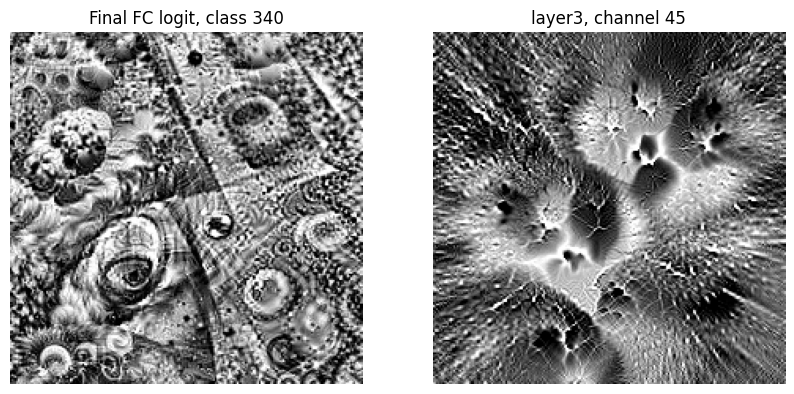

In [14]:
target_class = 340   # zebra

def get_fc_activation(scores, hook):
    return scores[:, target_class]

img_final = visualise(get_fc_activation, layer_module=None)

chosen_layer = model.layer3
channel_to_visualise = 45

def get_channel_activation(scores_unused, hook):
    return hook.activations[:, channel_to_visualise]

img_mid = visualise(get_channel_activation, layer_module=chosen_layer)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_final, cmap="gray")
axes[0].set_title(f"Final FC logit, class {target_class}")
axes[0].axis("off")

axes[1].imshow(img_mid, cmap="gray")
axes[1].set_title(f"layer3, channel {channel_to_visualise}")
axes[1].axis("off")

plt.show()


Think🤔: Which image is cleaner and more texture-like? Which one actually "looks like" the target class? Was your earlier prediction (about early vs late layers) correct?

Extension😈: Try swapping chosen_layer for model.layer1, model.layer2, and model.layer4, and try several different channel_to_visualise values. Can you find a channel that seems to respond to stripes? Dots? Specific colours (remember — colour patterns can still show up as light/dark grayscale textures, even without colour channels)?

Extension😈: Try increasing n_transforms from 4 to 16 (if your GPU can handle it). Does the image get noticeably cleaner? What's the trade-off? (Hint: think about how long each step now takes!)

Wrap-up ✅
You've now built a full pipeline for peering inside a CNN:

Flipping the usual training process to optimise pixels instead of weights
Designing a loss function with multiple competing goals (activation, intensity, smoothness)
Using a structural constraint (single-channel parameterisation) instead of a soft penalty to eliminate an unwanted degree of freedom
Using multi-scale (octave) optimisation to build coarse structure before fine detail
Hooking into intermediate layers to see the "vocabulary" of features a CNN builds up, from edges to whole objects
Using Expectation over Transformation to find robust, meaningful patterns rather than fragile noise
Extension😈 (for the very keen): The current state-of-the-art versions of this technique (used by Google's "Lucid" / "Lucent" libraries) go one step further: instead of optimising raw pixels at all, they optimise the image's Fourier spectrum directly, with a bias toward natural low-frequency structure. This single change produces dramatically crisper results than everything we've done today combined. If you want a real challenge, look up "Feature Visualization" by Olah et al. on Distill.pub, and try reimplementing their Fourier parameterisation yourself.

Great work — you've just reverse-engineered a neural network's imagination! 🧠🎨